In [1]:
%pip install casadi

Note: you may need to restart the kernel to use updated packages.


# 1. Etude du problème d’optimisation #
**Question 1 :** Justifier la forme de la dynamique de charge (1).

**Réponse :**
$\newline$


L'état de charge de la batterie à l'instant $i+1$ pour le véhicule $j$ correspond à l'état de charge à l'instant $i$ (i.e. $Q_{j,i}$) plus la charge apportée durant $∆t$ (entre $t_{i}$ et $t_{i+1}$). 
$\newline$
Cette charge apportée correspond à  $∆tβ_{j}P_{j,i}$ où : $∆t$ correspond au temps de charge, $P_{j,i}$ correspond à la puissance de la station de chargement $j$ et $β_{j}$ correspond au rendement de la batterie/au pourcentage de conversion de l'énergie de la zone de charge vers la batterie. 

**Question 2 :** Formuler le problème d’optimisation à résoudre sous la forme (5) :

$min_{x}$  $f(x)$  tel que :  $\quad c_{eq}(x) = 0\quad         c_{in}(x) ≤ 0$             

On précisera les variables de décision $x$, leur nombre $n$, les contraintes $c_{eq}$ et $c_{in}$ ainsi que la fonction
objectif $f$ à minimiser.*

**Réponse :**
$\newline$


On prend $P_{j,i}$ pour $i\in[0, …, N-1]$ et $j\in[1, …, N_{v}]$, comme variables de décisions. 
$\newline$
On a donc $N.N_{v}$ variables.
$\newline$
La quantitée qu'on cherche à minimiser est la suivante : $$∆t\sum\limits_{j=1}^{N_{v}} \sum\limits_{i=0}^N c_{i}P_{j, i}\newline$$
On peut donc poser : $$f~:~x\longrightarrow∆t\sum\limits_{j=1}^{N_{v}} \sum\limits_{i=0}^N c_{i}x_{j,i}$$
$\newline$
Concernant les contraintes : 
- $\forall~ i$ tel que $t_{i}\in [t_{j}^{in}, t_{j}^f], ~ Q_{j, i+1} - Q_{j, i} - \Delta t\beta_{j} P_{j, i}= 0$ ($\frac{t_{j}^f-t_{j}^{in}}{\Delta t}$ contraintes)
- $\forall~i, ~ \sum\limits_{j=1}^{N_{v}} P_{i,j} - \bar{P} \leq 0$ ($N$ contraintes)
- $\forall~j,~\forall~i,~ P_{j,i} \geq 0$ ($N.N_{v}$ contraintes)


**Je suis pas sur pour le comptage des contraintes. Une autre méthode, sugérée par Remi, était de prendre en variable P et Q mais comme P déterminer Q on peut ne pas le prendre si on veut. Je suis quasi sur que Raphael B et Laura ont fini ce projet en prenant que P en variable.**

**Question 3 :** Etudier la convexité de ce problème. Appartient-il à une famille particulière de problèmes d’optimisation ?

**Réponse :**
$\newline$

La fonction f que l'on cherche à minimiser est linéaire, elle est donc bien évidemment convexe. Ce problème appartient donc à la famille des problèmes d'optimisation convexe sous contraintes.



# 2. Identification du paramètre β #
**Question 4 :** On cherche à identifier le paramètre β à partir de ces essais, connaissant la charge maximale atteignable
$\bar{Q}$ (qui est elle simple à déterminer) et la tension secteur $U_{sec} = 230V$ , reliant puissance et intensité.
Formuler le problème de moindres carrés correspondant à l’identification de β.

**Réponse :**

Le document _'data_battery.csv'_ nous fournit le facteur de charge à l'instant i $SOC_{i}= \frac{Q_{i}}{\bar{Q}}$ et l'intensité à l'instant i  $I_{i}$ également. L'équation  $Q_{j, i+1} - Q_{j, i} - \Delta t\beta_{j} P_{j, i}= 0$ devient :
$$ SOC_{i+1}\bar{Q}-SOC_{i}\bar{Q} = \Delta t\beta U_{sec}I_{i}$$

En notant $\Delta SOC_{i} =SOC_{i+1}-SOC_{i}$ on a : 
$$ \Delta SOC_{i} = \frac{\Delta t\beta U_{sec}I_{i}}{\bar{Q}}$$

Grâce à _'data_battery.csv'_ on peut calculer facilement $\Delta SOC_{i}^{expérimental}$.
$\newline$
Pour le problème de moindres carrés on considère la fonction $g$ suivante :
$$g(\beta) = \sum\limits_{i=1}^{N} (\Delta SOC_{i}^{expérimental} - \frac{\Delta t\beta U_{sec}I_{i}}{\bar{Q}})^2$$


Il suffit maintenant de minimiser $g$ pour trouver la valeur de $\beta$. Supposons que $g$ atteint un minimum en $\beta^*$, alors on a $\beta = \beta^*$

**Question 5 :** Charger les données à l’aide du fichier data_battery.csv et résoudre ce problème pour $\bar{Q} = 50Ah$.
On pourra utiliser la solution des moindres carrés, ou utiliser la fonction numpy.linalg.lstsq. On
n’oubliera pas de filtrer convenablement le bruit de mesure, si besoin, et de commenter l’impact de ce
filtrage sur les résultats obtenus. On tracera en particulier sur la même figure l’évolution de l’état de
charge de la batterie au cours du temps, ainsi que l’état de charge estimé obtenu à partir de l’intensité
et du paramètre estimé β.

**Réponse :**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import casadi as ca
import numpy as np
import scipy as sp

df = pd.read_csv('data_battery.csv')
# Il y a une erreur dans le csv : les batteries se déchargent au lieu de se charger. Il faut inverser les données pour que ça marche.
df['SOC [%]'] = df['SOC [%]'].values[::-1]
df['I [kA]'] = df['I [kA]'].values[::-1]

Q_barre = 50
d_t = 1
U = 230

# On définit la fonction à minimiser
def g(beta):
    S = 0
    for i in range(len(df)-1):
        S += ((df['SOC [%]'][i+1] - df['SOC [%]'][i])-(d_t*beta*U*df['I [kA]'][i])/(Q_barre))**2
    return S
# On utilise la fonction minimize_scalar de scipy pour trouver le minimum de g
beta = sp.optimize.minimize_scalar(g).x
print(beta)

-0.000871739801903361


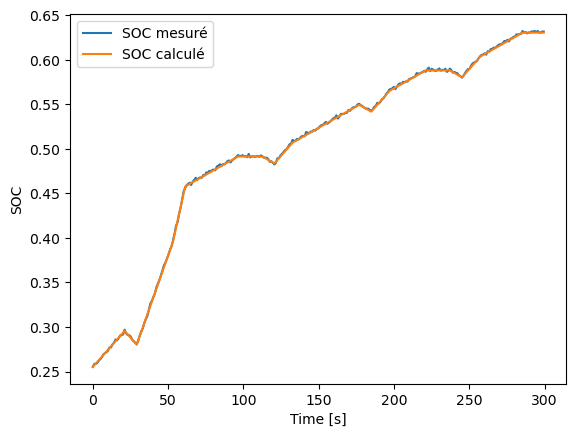

In [43]:
SOC_calcule = [df['SOC [%]'].iloc[0]] 
for i in range(len(df) - 1):
    delta_Q = (d_t * beta * U * df['I [kA]'].iloc[i]) / Q_barre
    nouveau_soc = SOC_calcule[-1] + delta_Q
    SOC_calcule.append(nouveau_soc)


plt.plot(df['Time [s]'], df['SOC [%]'], label='SOC mesuré')
plt.plot(df['Time [s]'], SOC_calcule, label='SOC calculé')
plt.xlabel('Time [s]')
plt.ylabel('SOC')
plt.legend()
plt.show()

# 3. Etude et résolution numérique du problème centralisé #
**Question 6 :** Quelles méthodes de résolution peuvent être envisagées pour ce problème ? 

**Réponse :**

**Question 7 :** Développer un algorithme de résolution dans le cas d’un horizon de temps de $24h (t_{0} = 17h, ∆t =
0.25h)$, avec :
$\newline$
• un tarif d’heure creuse ($c_{i} = c_{cr}$ constant) entre d’une part minuit et $6h$, et d’autre part $12h$ et $14h$
et un tarif d’heure pleine ($c_{i} = c_{pl}$ constant) le reste du temps ;
$\newline$
• un premier véhicule qui arrive avec un état de charge de $30%$ à $18h$ et souhaite repartir à $8h$ le
lendemain matin ;
$\newline$
• un second véhicule qui arrive avec un état de charge de $50%$ à $18h30$ et souhaite repartir à $9h$ le
lendemain.
$\newline$
On prendra les valeurs numériques suivantes :
$\newline$
$$c_{cr} = 1 , c_{pl} = 3/2 , \bar{Q} = 50Ah , \bar{P} = 2.5kW (6)$$
$\newline$
On veillera à afficher au minimum les graphiques suivants :$\newline$
(a) l’évolution de l’état de charge de chaque véhicule au cours du temps ainsi que la puissance (normalisée) fournie à chaque véhicule. On prendra soin d’indiquer les temps de contrainte de pleine
charge des véhicules.
$\newline$
(b) l’évolution de la puissance totale (normalisée) fournie à la flotte, au cours du temps, ainsi que
celle du tarif électrique.
$\newline$
Commenter les résultats obtenus.

**Réponse :**

**Question 8:** Quels inconvénients présente cette solution centralisée ? (On pourra penser aux données dont doit
disposer l’optimiseur pour la résolution.)

**Réponse :**